In [ ]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
try:
    import shap
    SHAP_AVAILABLE = True
except:
    SHAP_AVAILABLE = False


In [ ]:
def standardize_columns(df):
    df = df.copy()
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.lower()
        .str.replace(r"\s+", "_", regex=True)
    )
    return df

def cap_iqr(s):
    # Cap outliers using IQR method (keeps all rows)
    s = pd.to_numeric(s, errors="coerce")
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    return s.clip(low, high)

def print_metrics(y_true, y_pred, y_proba):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_proba)
    return acc, prec, rec, f1, auc

def sanitize_feature_names(columns):
    cols = [str(c) for c in columns]
    cols = [re.sub(r"[^0-9a-zA-Z_]+", "_", c) for c in cols]
    cols = [c if c.strip() else "feature" for c in cols]
    seen = {}
    out = []
    for c in cols:
        if c not in seen:
            seen[c] = 1
            out.append(c)
        else:
            seen[c] += 1
            out.append(f"{c}_{seen[c]}")
    return out

In [ ]:
df = pd.read_csv("/content/sample_data/bank_churn_data.csv")
print("Shape:", df.shape)

df = standardize_columns(df)


Shape: (50000, 14)


In [ ]:
target_candidates = ["exited", "churned", "churn"]
target_col = None

for c in target_candidates:
    if c in df.columns:
        target_col = c
        break

if target_col is None:
    raise ValueError("Target column not found.")

if df[target_col].dtype == "object":
    df[target_col] = (
        df[target_col].astype(str).str.strip() .str.lower()
        .replace({"yes":1, "no":0, "true":1, "false":0})
    )

df[target_col] = pd.to_numeric(df[target_col], errors="coerce").fillna(0).astype(int)
id_cols = [c for c in ["rownumber", "customerid", "surname"]if c in df.columns]

df = df.drop_duplicates().reset_index(drop=True)

In [ ]:
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
num_cols = [c for c in df.columns if c not in cat_cols]

for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

for c in num_cols:
    if df[c].isna().sum() > 0:
        df[c] = df[c].fillna(df[c].median())

for c in cat_cols:
    if df[c].isna().sum() > 0:
        df[c] = df[c].fillna(df[c].mode().iloc[0])


for col in ["balance", "estimatedsalary"]:
    if col in df.columns:
        df[col] = cap_iqr(df[col])

if "tenure" in df.columns:
    df["tenure_group"] = pd.cut(
        df["tenure"],
        bins=[-1, 2, 6, 10],
        labels=["new", "mid_term", "loyal"]
    ).astype(str)

if "balance" in df.columns and "estimatedsalary" in df.columns:
    df["balance_salary_ratio"] = df["balance"] / (df["estimatedsalary"] + 1e-9)

eng = 0
if "numofproducts" in df.columns:
    eng = eng + df["numofproducts"]
if "isactivemember" in df.columns:
    eng = eng + df["isactivemember"]
if "hascrcard" in df.columns:
    eng = eng + df["hascrcard"]
df["engagement_score"] = pd.to_numeric(eng, errors="coerce").fillna(0)

if "isactivemember" in df.columns and "numofproducts" in df.columns:
    df["active_x_products"] = df["isactivemember"] * df["numofproducts"]

--------------------EDA----------------------------

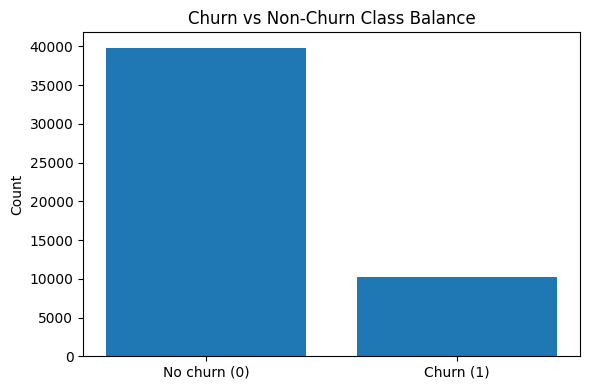

In [ ]:
#Class balance
counts = df[target_col].value_counts().sort_index()
plt.figure(figsize=(6,4))
plt.bar(["No churn (0)","Churn (1)"], [counts.get(0,0),counts.get(1,0)])
plt.title("Churn vs Non-Churn Class Balance")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

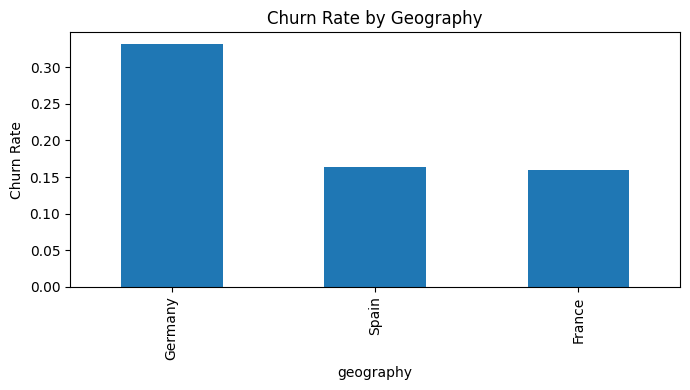

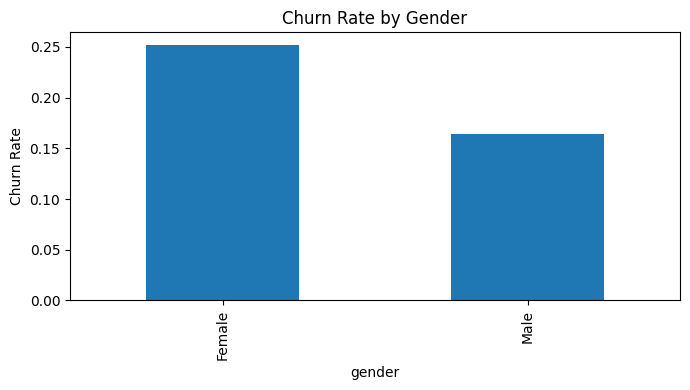

In [ ]:
# Churn rates by Geography / Gender

for c in ["geography", "gender"]:

    if c in df.columns:

        churn_rate = (
            df.groupby(c)[target_col]
            .mean()
            .sort_values(ascending=False)
        )

        plt.figure(figsize=(7,4))
        churn_rate.plot(kind="bar")

        plt.title(f"Churn Rate by {c.title()}")
        plt.ylabel("Churn Rate")

        plt.tight_layout()
        plt.show()

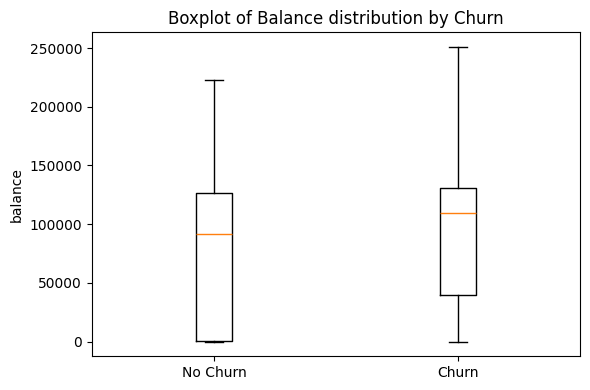

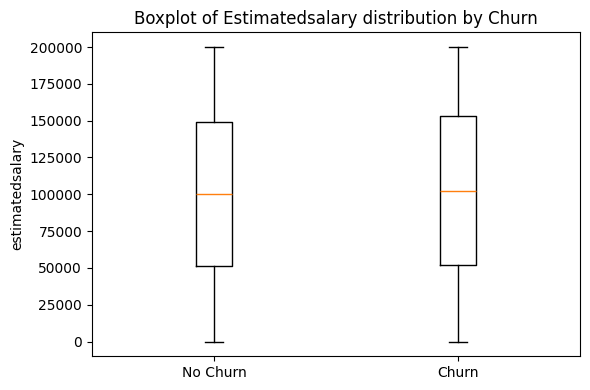

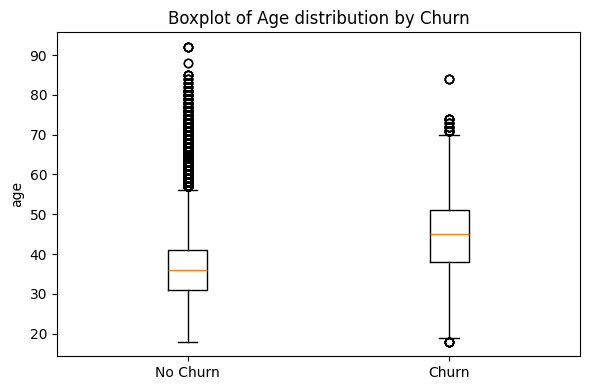

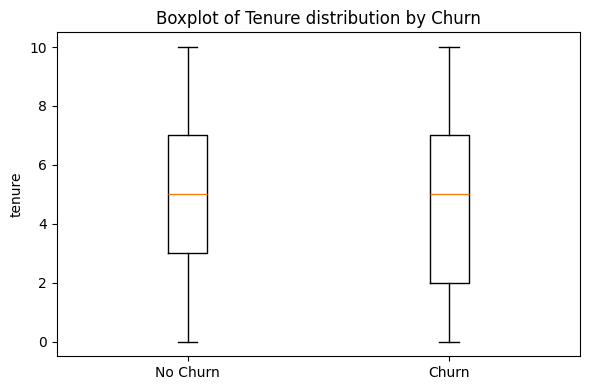

In [ ]:
#Balance vs Churn ,Tenure vs Churn(Boxplots)
def boxplot_by_target(feature):
  if feature in df.columns:
    plt.figure(figsize=(6,4))
    data0=df[df[target_col]==0][feature].dropna()
    data1=df[df[target_col]==1][feature].dropna()
    plt.boxplot([data0,data1],labels=["No Churn","Churn"])
    plt.title(f"Boxplot of {feature.title()} distribution by Churn")
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()

for feat in ["balance","estimatedsalary","age" ,"tenure"]:
  boxplot_by_target(feat)



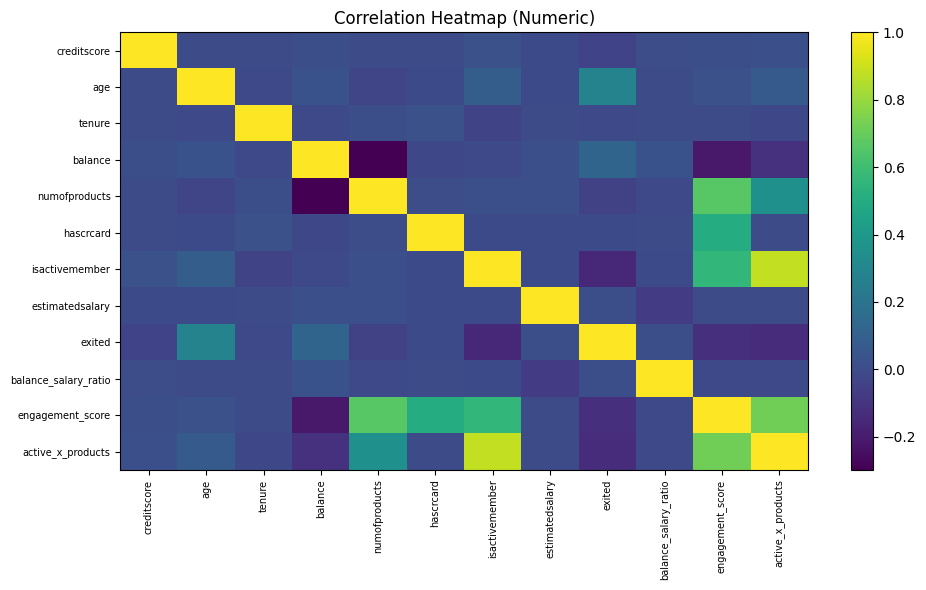

In [ ]:
#correlation heatmap(numeric)
num_for_corr=df.select_dtypes(include=[ np.number]).drop(columns=id_cols,errors="ignore")
corr=num_for_corr.corr()
plt.figure(figsize=(10,6))
plt.imshow(corr,aspect="auto")
plt.colorbar()
plt.title("Correlation Heatmap (Numeric)")
plt.xticks(range(len(corr.columns)),corr.columns,rotation=90,fontsize=7)
plt.yticks(range(len(corr.columns)),corr.columns,fontsize=7)
plt.tight_layout()
plt.show()

---------------------Prepare ML Data------------------

In [ ]:
#Drop IDs from features

X = df.drop(columns=id_cols + [target_col], errors="ignore").copy()
y = df[target_col].copy()
# One-hot encode
X = pd.get_dummies(X, drop_first=True)
#sanitize feature names
X.columns = sanitize_feature_names(X.columns)
#Ensure numeric and clean inf/nan
X = X.replace([np.inf,-np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:


#Scaling for distance based models
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)
#Imbalance handling
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
X_train_sc_sm, y_train_sc_sm = sm.fit_resample(X_train_sc, y_train)
print("SMOTE applied on training data")

SMOTE applied on training data


------------------------Train Models + compare----------------------------

In [ ]:
results = []
trained = {}

In [ ]:
lr = LogisticRegression(max_iter=2000)

lr.fit(X_train_sc_sm, y_train_sc_sm)

proba = lr.predict_proba(X_test_sc)[:,1]
pred = (proba >= 0.5).astype(int)

acc, prec, rec, f1, auc = print_metrics(y_test, pred, proba)

results.append(["Logistic Regression", acc, prec, rec, f1, auc])
trained["Logistic Regression"] = ("scaled", lr)

In [ ]:
knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(X_train_sc_sm, y_train_sc_sm)
proba = knn.predict_proba(X_test_sc)[:,1]
pred = (proba >= 0.5).astype(int)
acc, prec, rec, f1, auc = print_metrics(y_test, pred, proba)
results.append(["KNN", acc, prec, rec, f1, auc])
trained["KNN"] = ("scaled", knn)

In [ ]:
rf = RandomForestClassifier(n_estimators=400, random_state=42)

rf.fit(X_train_sm, y_train_sm)

proba = rf.predict_proba(X_test)[:,1]
pred = (proba >= 0.5).astype(int)

acc, prec, rec, f1, auc = print_metrics(y_test, pred, proba)

results.append(["Random Forest", acc, prec, rec, f1, auc])
trained["Random Forest"] = ("raw", rf)

In [ ]:
#SVM

svm = SVC(kernel="rbf",C = 2.0,gamma="scale",probability=True,class_weight=None)

svm.fit(X_train_sc_sm, y_train_sc_sm)

proba = svm.predict_proba(X_test_sc)[:,1]
pred = (proba >= 0.5).astype(int)

acc, prec, rec, f1, auc = print_metrics(y_test, pred, proba)

results.append(["SVM", acc, prec, rec, f1, auc])
trained["SVM"] = ("scaled", svm)

In [ ]:
#XGB

# scale_pos_weight helps when not using SMOTE
pos = int((y_train == 1).sum())
neg = int((y_train == 0).sum())
spw = (neg / max(pos,1))


xgb = XGBClassifier(n_estimators=600, max_depth=4, learning_rate=0.05,subsample=0.9,
                    colsample_bytree=0.9,reg_lambda=1.0,random_state=42,eval_metric="logloss",
                    scale_pos_weight=1.0)

xgb.fit(X_train_sm, y_train_sm)

proba = xgb.predict_proba(X_test)[:,1]
pred = (proba >= 0.5).astype(int)

acc, prec, rec, f1, auc = print_metrics(y_test, pred, proba)

results.append(["XGBoost", acc, prec, rec, f1, auc])
trained["XGBoost"] = ("raw", xgb)

In [ ]:
#Results table
res_df = pd.DataFrame(results, columns=[
    "Model","Accuracy","Precision","Recall","F1","ROC_AUC"
])

res_df = res_df.sort_values("ROC_AUC", ascending=False)
print(res_df)

best_name = res_df.iloc[0]["Model"]
best_mode,best_model = trained[best_name]

print("\nBest Model:", best_name," | Input:",best_mode)

                 Model  Accuracy  Precision    Recall        F1   ROC_AUC
2        Random Forest    0.9906   0.979753  0.973981  0.976859  0.998407
1                  KNN    0.9275   0.751727  0.961708  0.843851  0.988733
4              XGBoost    0.8655   0.645746  0.752577  0.695080  0.914372
3                  SVM    0.8450   0.585051  0.822288  0.683673  0.912004
0  Logistic Regression    0.7071   0.380685  0.698576  0.492814  0.772001

Best Model: Random Forest  | Input: raw


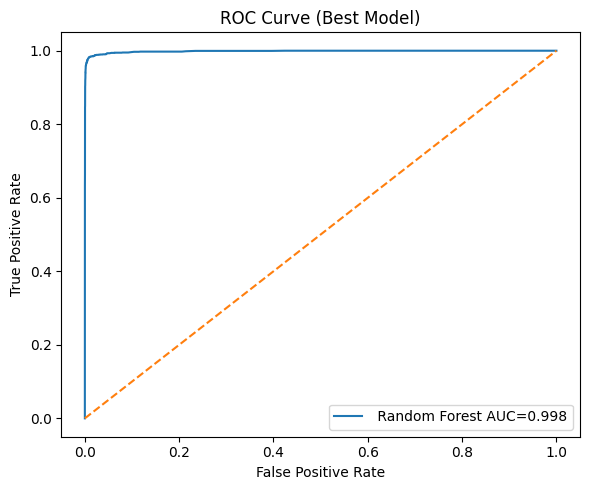

In [ ]:
# ROC curve for best model

if best_mode == "scaled":
    proba_best = best_model.predict_proba(X_test_sc)[:,1]
else:
    proba_best = best_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, proba_best)
auc_best = roc_auc_score(y_test, proba_best)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f" {best_name} AUC={auc_best:.3f}")
plt.plot([0,1],[0,1],linestyle="--")
plt.title("ROC Curve (Best Model)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

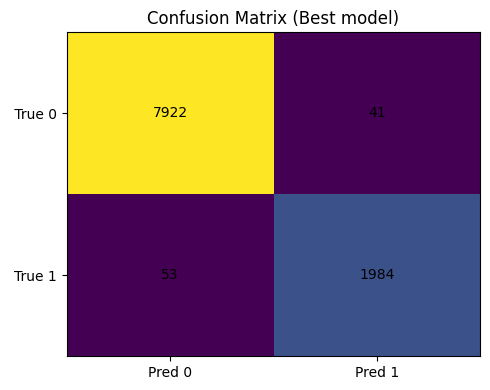

In [ ]:
# Confusion matrix (best)
pred_best = (proba_best >= 0.5).astype(int)
cm = confusion_matrix(y_test, pred_best)

plt.figure(figsize=(5,4))
plt.imshow(cm,aspect="auto")
plt.title("Confusion Matrix (Best model)")
plt.xticks([0,1],["Pred 0","Pred 1"])
plt.yticks([0,1],[" True 0","True 1"])
for (i,j), val in np.ndenumerate(cm):
    plt.text(j,i,str(val),ha="center",va="center")
plt.tight_layout()
plt.show()

-------------------Explainability(SHAP/Fallback)---------------

In [ ]:
#shap

try:
    if SHAP_AVAILABLE and best_name in ["Random Forest","XGBoost"]:
        X_explain = X_test_sample(n=min(500,len(X_test)),random_state=42)
        explainer = shap.TreeExplainer(best_model)
        shap_values = explainer.shap_values(X_explain)

        shap.summary_plot(shap_values, X_explain,show=False)
        plt.title("SHAP Summary Plot (Best Model)")
        plt.tight_layout()
        plt.show()
        print("SHAP Summary Plotted.")
    else:
      #Fallbacks
      if best_name == "Logistic Regression":
        #coefficients
        coefs=pd.Series(best_model.coef_[0],index=X_train.columns).sort_values(key=np.abs,ascending=False).head(15)
        plt.figure(figsize=(10,4))
        plt.bar(coefs.index,coefs.values)
        plt.title(" Top 15 Logistic Regression Coefficients")
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()
        print("Logistic Regression coefficients plotted.")
      elif best_name == "Random Forest":
        imp = pd.Series(best_model.feature_importances_,index=X_train.columns).sort_values(ascending=False).head(15)
        plt.figure(figsize=(10,4))
        plt.bar(imp.index,imp.values)
        plt.title("Top 15 Random Forest Feature Importance")
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()
        print("Random Forest feature importance plotted.")
      elif best_name == "XGBoost" and hasattr(best_model,"feature_importances_"):
        imp = pd.Series(best_model.feature_importances_,index=X_train.columns).sort_values(ascending=False).head(15)
        plt.figure(figsize=(10,4))
        plt.bar(imp.index,imp.values)
        plt.title("Top 15 XGBoost Feature Importance")
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()
        print("XGBoost feature importance plotted.")
      else:
        print("SHAP not used;explaiability fallback not available for this model.")
except Exception as e:
    print("Explaiability step failed",e)

Explaiability step failed name 'X_test_sample' is not defined


-----------------Predict for New Customer-----------------

In [ ]:
#Build a template row with default/median values
template = X_train.median(numeric_only=True).to_dict()

#example:we can edit these values
new_customer = template.copy()

#try to set some column fields if they exist in the one-hot encoded coloums
for col in X_train.columns:
  if col.startswith("gender_") or col.startswith("geography_"):
    new_customer[col]=0  #reset all categories

#example selections (only if those columns exist)
if "gender_male" in new_customer:
  new_customer["gender_male"]=1
if "geography_germany" in new_customer:
  new_customer["geography_germany"]=1

#Try numeric fields (if present)
for k,v in [
    ("creditscore",650),
    ("age",40),
    ("tenure",5),
    ("balance",75000),
    ("numofproducts",2),
    ("hascrcard",1),
    ("isactivemember",1),
    ("estimatedsalary",90000),
    ("balance_salary_ratio",0.83),
    ("engagement_score",5),
    ("active_x_products",2),
]:
    if k in new_customer:
      new_customer[k]=v

new_df = pd.DataFrame([new_customer])[X_train.columns]

if best_mode == "scaled":
    new_sc = scaler.transform(new_df)
    churn_prob = float(best_model.predict_proba(new_sc)[:,1][0])
else:
    churn_prob = float(best_model.predict_proba(new_df)[:,1][0])

print("Predicted churn probability:", round(churn_prob,4))
print("Predicted class (>=0.5 churn): ", int(churn_prob>=0.5))

Predicted churn probability: 0.34
Predicted class (>=0.5 churn):  0
